In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv('initial data_ref.csv')
#data = pd.read_csv('initial data_cal_cubic.csv')
#data = pd.read_csv('initial data_cal_rhom.csv')
data

,Unnamed: 0,Band gap (eV),Structure,A-site,B-site,B'-site,X-site,W_B,EN_B,EA_B,1IE_B,2IE_B,3IE_B,D_B,S_B,HV_B,W_X,S_X,t(AR),u(IR)
0,CsBaBr3,5.14,ABX3,Cs,Ba,NaN,Br,137.33,0.89,13.95,502.9,965.2,3600.0,3510.0,205.0,140.0,79.90,947.3,0.80,0.69
1,CsBaCl3,6.00,ABX3,Cs,Ba,NaN,Cl,137.33,0.89,13.95,502.9,965.2,3600.0,3510.0,205.0,140.0,35.45,478.2,0.80,0.75
2,CsBaI3,4.31,ABX3,Cs,Ba,NaN,I,137.33,0.89,13.95,502.9,965.2,3600.0,3510.0,205.0,140.0,126.90,429.0,0.79,0.61
3,CsBeBr3,2.01,ABX3,Cs,Be,NaN,Br,9.01,1.57,-48.00,899.5,1757.1,14848.7,1848.0,1820.0,297.0,79.90,947.3,1.35,0.23
4,CsBeCl3,3.68,ABX3,Cs,Be,NaN,Cl,9.01,1.57,-48.00,899.5,1757.1,14848.7,1848.0,1820.0,297.0,35.45,478.2,1.40,0.25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
209,Cs4VCl6,3.26,A4BX6,Cs,V,NaN,Cl,50.94,1.63,50.60,650.9,1414.0,2830.0,6110.0,489.0,453.0,35.45,478.2,1.07,0.30
210,Cs4VI6,3.46,A4BX6,Cs,V,NaN,I,50.94,1.63,50.60,650.9,1414.0,2830.0,6110.0,489.0,453.0,126.90,429.0,1.02,0.25
211,Cs4ZnBr6,4.37,A4BX6,Cs,Zn,NaN,Br,65.38,1.65,-58.00,906.4,1733.3,3833.0,7140.0,388.0,119.0,79.90,947.3,1.17,0.38
212,Cs4ZnCl6,5.47,A4BX6,Cs,Zn,NaN,Cl,65.38,1.65,-58.00,906.4,1733.3,3833.0,7140.0,388.0,119.0,35.45,478.2,1.21,0.41


In [3]:
def map_structure(Structure):
    if 'ABX3' in Structure:
        return 'ABX3'
    elif 'A2BX6' in Structure:
        return 'A2BX6'
    elif "A2BB'X6" in Structure:
        return "A2BB'X6"
    elif 'A3B2X9' in Structure:
        return 'A3B2X9'
    elif 'A4BX6' in Structure:
        return 'A4BX6'
    
data['Structure_Family'] = data['Structure'].apply(map_structure)

/var/folders/7j/zq0kvr6x3896hqp7_jr600dc0000gn/T/ipykernel_37965/3141029867.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/var/folders/7j/zq0kvr6x3896hqp7_jr600dc0000gn/T/ipykernel_37965/3141029867.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([nice_labels[label] for label in structure_families])


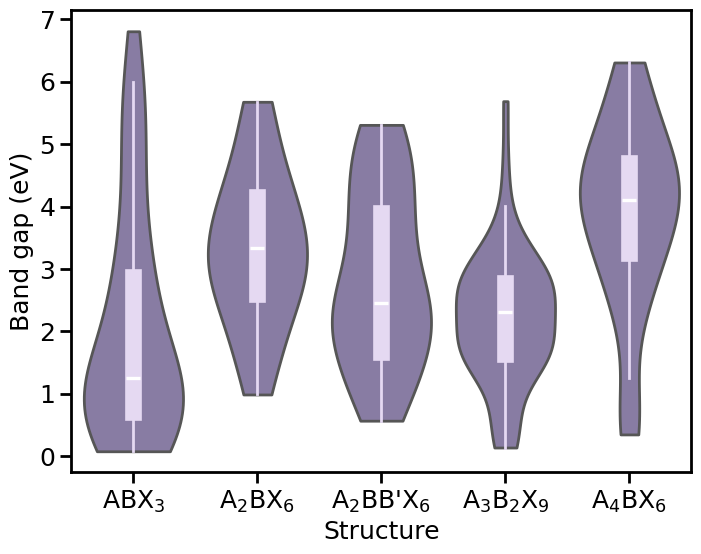

In [4]:
plt.figure(figsize=(8, 6))  

custom_palette = {
    'ABX3': '#8675A9', 
    'A2BX6': '#8675A9', 
    "A2BB'X6": '#8675A9', 
    'A3B2X9': '#8675A9', 
    'A4BX6': '#8675A9'
}

ax = sns.violinplot(
    data=data, 
    x='Structure_Family', 
    y='Band gap (eV)', 
    inner='box', 
    inner_kws=dict(box_width=12, whis_width=2, color='#E5D9F2'),
    palette=custom_palette, 
    cut=0, 
    linewidth=2
)

structure_families = data['Structure_Family'].unique()

nice_labels = {
    'ABX3': r'ABX$_3$', 
    'A2BX6': r'A$_2$BX$_6$',
    "A2BB'X6": r"A$_2$BB'X$_6$",
    'A3B2X9': r'A$_3$B$_2$X$_9$',
    'A4BX6': r'A$_4$BX$_6$'
}
ax.set_xticklabels([nice_labels[label] for label in structure_families])
plt.xlabel('Structure', fontsize=18)
plt.ylabel('Band gap (eV)', fontsize=18)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.tick_params(axis='both', width=2, length=8)
ax.spines['left'].set_linewidth(2)
ax.spines['right'].set_linewidth(2)
ax.spines['top'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)
plt.savefig('structure.jpeg', format='jpeg', dpi=300)
plt.show()

In [5]:
percentiles = data.groupby('Structure_Family')['Band gap (eV)'].quantile([0.25, 0.5, 0.75]).unstack()
percentiles.columns = ['Q1 (25%)', 'Median (50%)', 'Q3 (75%)']
print(percentiles)

                  Q1 (25%)  Median (50%)  Q3 (75%)
Structure_Family                                  
A2BB'X6             1.6700         2.460    3.9000
A2BX6               2.5975         3.345    4.1475
A3B2X9              1.6350         2.305    2.7700
A4BX6               3.2600         4.105    4.7025
ABX3                0.7100         1.260    2.8700


In [6]:
def map_asite(asite):
    if 'Cs' in asite:
        return 'Cs'
    if 'K' in asite:
        return 'K'
    if 'Rb' in asite:
        return 'Rb'
    if 'Na' in asite:
        return 'Na'
    
data['A_site'] = data['A-site'].apply(map_asite)

/var/folders/7j/zq0kvr6x3896hqp7_jr600dc0000gn/T/ipykernel_37965/3467556902.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(


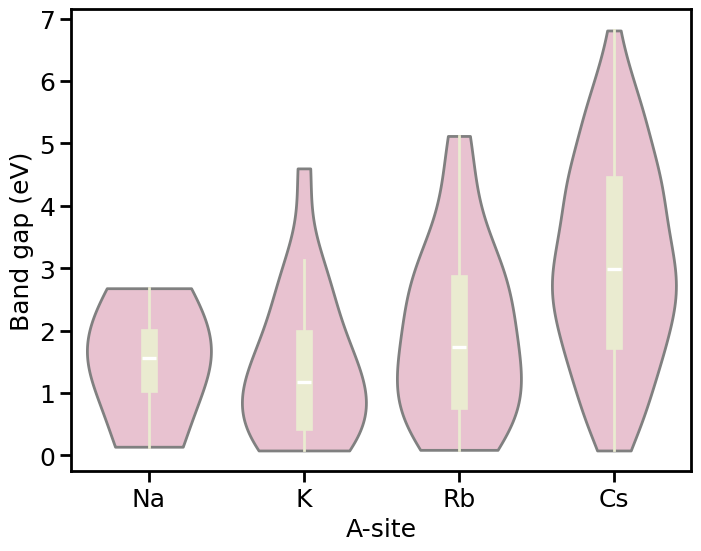

In [7]:
asite_order = ['Na', 'K', 'Rb', 'Cs']
plt.figure(figsize=(8, 6))  

custom_palette = {
    'Na': '#EFBBCF', 
    'K': '#EFBBCF', 
    'Rb': '#EFBBCF', 
    'Cs': '#EFBBCF', 
}

ax = sns.violinplot(
    data=data, 
    x='A_site', 
    y='Band gap (eV)', 
    inner='box', 
    inner_kws=dict(box_width=12, whis_width=2, color='#EAEBD0'),
    palette=custom_palette, 
    cut=0, 
    linewidth=2,
    order=asite_order  

)

plt.xlabel('A-site', fontsize=18)
plt.ylabel('Band gap (eV)', fontsize=18)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.tick_params(axis='both', width=2, length=8)
ax.spines['left'].set_linewidth(2)
ax.spines['right'].set_linewidth(2)
ax.spines['top'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)
plt.savefig('A-site.jpeg', format='jpeg', dpi=300)
plt.show()

In [8]:
asite_elements = ['Na', 'K', 'Rb', 'Cs']

stats = (
    data[data['A_site'].isin(asite_elements)]
    .groupby('A_site')['Band gap (eV)']
    .agg(
        Q1_25=lambda x: x.quantile(0.25),
        Median_50=lambda x: x.quantile(0.5),
        Q3_75=lambda x: x.quantile(0.75),
        Min='min',
        Max='max'
    )
    .reindex(asite_elements) 
)

stats.columns = ['Q1 (25%)', 'Median (50%)', 'Q3 (75%)', 'Min', 'Max']
print(stats)

        Q1 (25%)  Median (50%)  Q3 (75%)   Min   Max
A_site                                              
Na        1.1525         1.565    1.9000  0.14  2.68
K         0.5350         1.170    1.8775  0.08  4.60
Rb        0.8800         1.740    2.7700  0.09  5.12
Cs        1.8300         2.990    4.3550  0.08  6.81


In [9]:
def map_bsite(bsite):
    if bsite in ['Na', 'Cs', 'Rb', 'K']:
        return 'AM'
    if bsite in ['Ba', 'Be', 'Ca', 'Mg', 'Sr']:
        return 'AE'
    if bsite in ['Cd', 'Mn', 'Ni', 'V', 'Zn', 'Mo', 'Ti', 'W', 'Zr', 'Hf', 'Ag', 
                 'Cu', 'Cr', 'Fe', 'Sc']:
        return 'TM'
    if bsite in ['Pb', 'Sn', 'Al', 'Bi', 'Ga', 'In']:
        return 'PT'
    if bsite in ['Ge', 'Si', 'Te', 'As', 'B', 'Sb']:
        return 'MT'

data['B_site'] = data['B-site'].apply(map_bsite)

/var/folders/7j/zq0kvr6x3896hqp7_jr600dc0000gn/T/ipykernel_37965/3576956878.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(


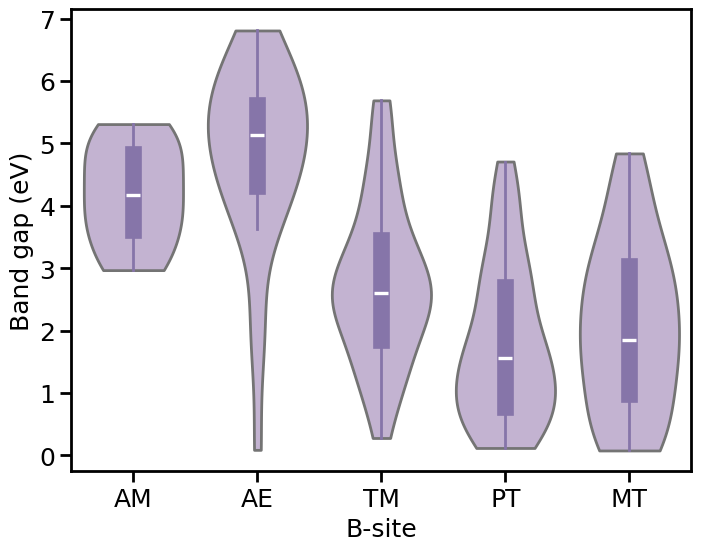

In [10]:
bsite_order = ['AM', 'AE', 'TM', 'PT', 'MT']
plt.figure(figsize=(8, 6))

custom_palette = {
    'AM': '#C3AED6', 
    'AE': '#C3AED6', 
    'TM': '#C3AED6',
    'PT': '#C3AED6',
    'MT': '#C3AED6'
}

ax = sns.violinplot(
    data=data, 
    x='B_site', 
    y='Band gap (eV)', 
    inner='box', 
    inner_kws=dict(box_width=12, whis_width=2, color='#8675A9'),
    palette=custom_palette, 
    cut=0, 
    linewidth=2,
    order=bsite_order  
)

plt.xlabel('B-site', fontsize=18)
plt.ylabel('Band gap (eV)', fontsize=18)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.tick_params(axis='both', width=2, length=8)
ax.spines['left'].set_linewidth(2)
ax.spines['right'].set_linewidth(2)
ax.spines['top'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)
plt.savefig('B-site.jpeg', format='jpeg', dpi=300)
plt.show()

In [11]:
bsite_order = ['AM', 'AE', 'TM', 'PT', 'MT']

stats = (
    data[data['B_site'].isin(bsite_order)]
    .groupby('B_site')['Band gap (eV)']
    .agg(
        Q1_25=lambda x: x.quantile(0.25),
        Median_50=lambda x: x.quantile(0.5),
        Q3_75=lambda x: x.quantile(0.75),
        Min='min',
        Max='max'
    )
    .reindex(bsite_order) 
)

stats.columns = ['Q1 (25%)', 'Median (50%)', 'Q3 (75%)', 'Min', 'Max']
print(stats)

        Q1 (25%)  Median (50%)  Q3 (75%)   Min   Max
B_site                                              
AM        3.6200         4.170     4.835  2.97  5.31
AE        4.3100         5.140     5.620  0.09  6.81
TM        1.8575         2.600     3.450  0.28  5.69
PT        0.7700         1.565     2.695  0.12  4.71
MT        0.9775         1.855     3.040  0.08  4.84


In [12]:
def map_halogen(xsite):
    if 'Cl' in xsite:
        return 'Cl'
    if 'Br' in xsite:
        return 'Br'
    if 'I' in xsite:
        return 'I'

data['Halogen_site'] = data['X-site'].apply(map_halogen)

/var/folders/7j/zq0kvr6x3896hqp7_jr600dc0000gn/T/ipykernel_37965/1072284130.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(


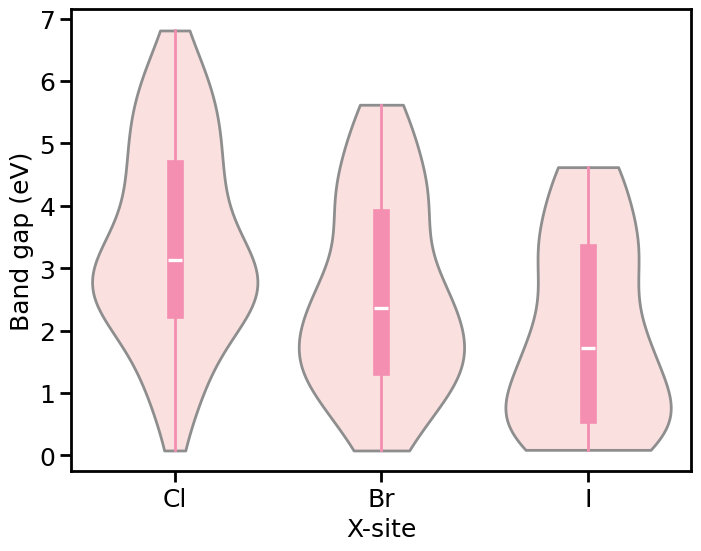

In [13]:
halogen_order = ['Cl', 'Br', 'I']
plt.figure(figsize=(8, 6))

custom_palette = {
    'Cl': '#FFDBDB', 
    'Br': '#FFDBDB', 
    'I': '#FFDBDB'
}

ax = sns.violinplot(
    data=data, 
    x='Halogen_site', 
    y='Band gap (eV)', 
    inner='box', 
    inner_kws=dict(box_width=12, whis_width=2, color='#F48FB1'),
    palette=custom_palette, 
    cut=0, 
    linewidth=2,
    order=halogen_order  
)

plt.xlabel('X-site', fontsize=18)
plt.ylabel('Band gap (eV)', fontsize=18)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.tick_params(axis='both', width=2, length=8)
ax.spines['left'].set_linewidth(2)
ax.spines['right'].set_linewidth(2)
ax.spines['top'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)
plt.savefig('X-site.jpeg', format='jpeg', dpi=300)
plt.show()

In [14]:
stats = data.groupby('Halogen_site')['Band gap (eV)'].agg(
    Q1_25=lambda x: x.quantile(0.25),
    Median_50=lambda x: x.quantile(0.5),
    Q3_75=lambda x: x.quantile(0.75),
    Min='min',
    Max='max'
)

stats.columns = ['Q1 (25%)', 'Median (50%)', 'Q3 (75%)', 'Min', 'Max']
print(stats)

              Q1 (25%)  Median (50%)  Q3 (75%)   Min   Max
Halogen_site                                              
Br              1.4250         2.370    3.8250  0.08  5.62
Cl              2.3300         3.140    4.6000  0.08  6.81
I               0.6425         1.725    3.2675  0.09  4.62
